In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

In [ ]:
df_train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
df_test.head()
df_test.isnull().sum()

,0
id,0
Age,0
Annual_Income_USD,0
Daily_Commute_km,0
Number_of_Cars_Owned,0
Charging_Stations_Near_Home,0
Charging_Stations_Near_Work,0
Environmental_Concern_Level,0
Gender,0
City_Type,0


In [ ]:
df_train.shape

(668665, 15)

In [ ]:
df_test.shape

(286571, 14)

In [ ]:
df_test.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'],
      dtype='object')

In [ ]:
df_train.describe()


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [ ]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [ ]:
df_test.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000,286571.000000
mean,47.070824,84799.508432,32.159305,1.716095,4.950693,7.155626,2.934554
std,12.864850,28626.851098,18.724436,0.731088,3.928626,5.186880,1.427541
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67380.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84926.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102751.000000,47.300000,2.000000,7.000000,10.000000,4.000000
max,69.000000,186936.000000,103.900000,4.000000,14.000000,19.000000,5.000000


In [ ]:
# List all columns with 'object' or 'category' data types
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)


Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')


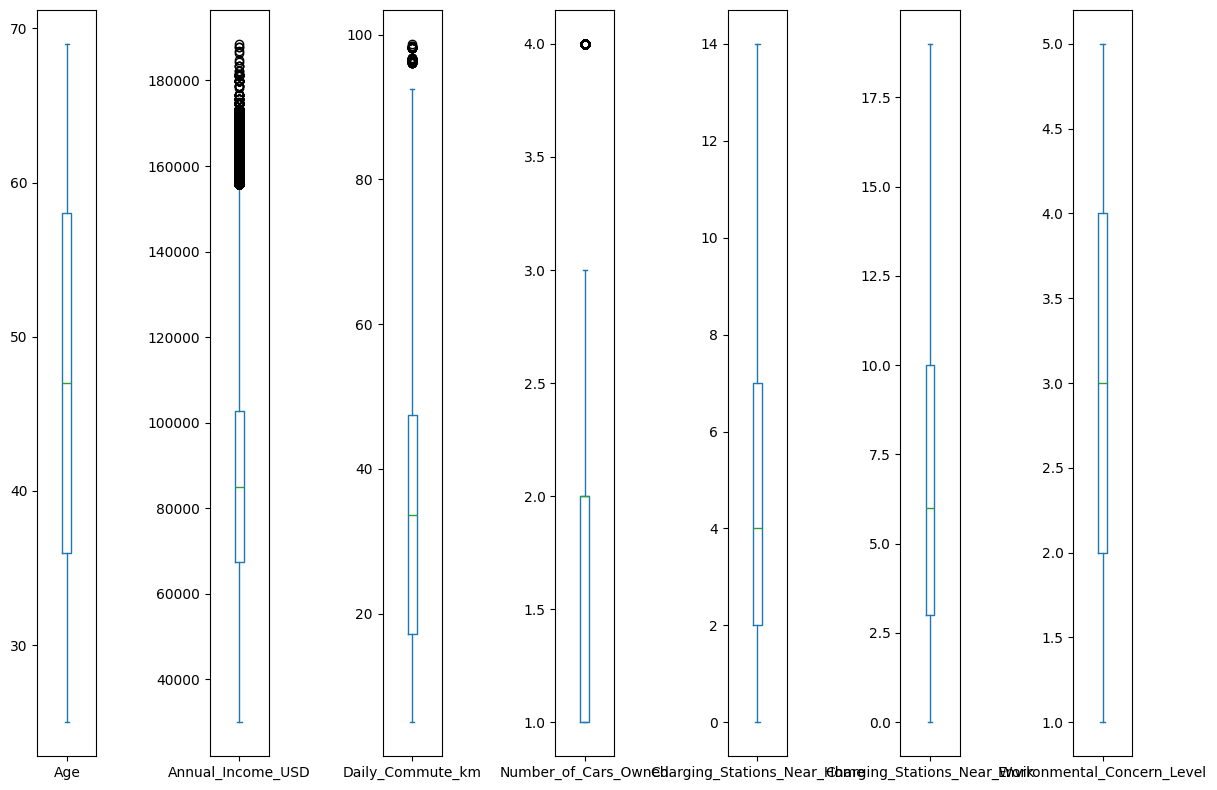

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_cols = df_train.select_dtypes(include=['number']).columns

# Plot each column in its own subplot to handle different scales
df_train[numerical_cols].plot(kind='box', subplots=True, figsize=(12, 8), sharex=False, sharey=False)

cols_to_plot = numerical_cols.drop(['id'], errors='ignore')

plt.tight_layout()
plt.show()


,0
Annual_Income_USD,"Axes(0.125,0.11;0.775x0.77)"


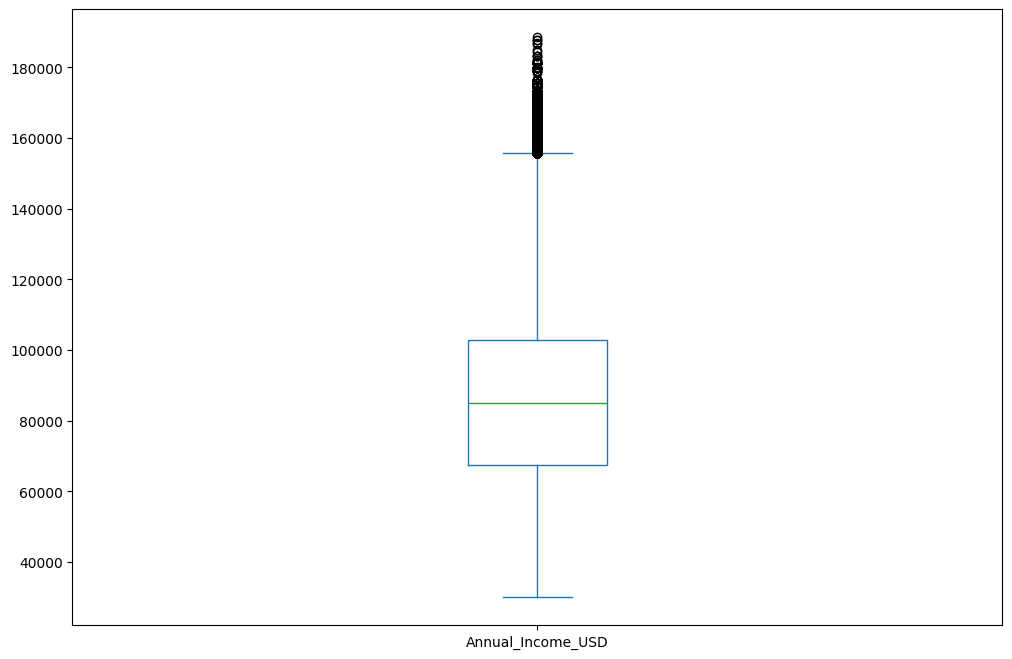

In [ ]:
df_train["Annual_Income_USD"].plot(kind='box', subplots=True, figsize=(12, 8), sharex=False, sharey=False)


,0
Daily_Commute_km,"Axes(0.125,0.11;0.775x0.77)"


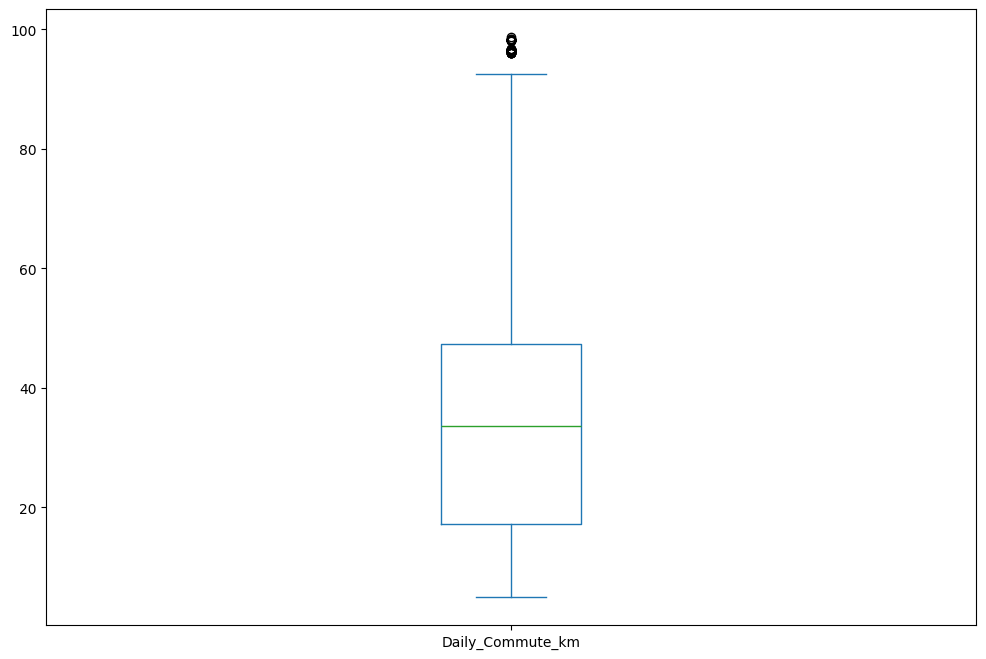

In [ ]:
df_train["Daily_Commute_km"].plot(kind='box', subplots=True, figsize=(12, 8), sharex=False, sharey=False)


In [ ]:
# 1. Calculate Q1, Q3, and IQR
Q1 = df_train['Daily_Commute_km'].quantile(0.25)
Q3 = df_train['Daily_Commute_km'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define upper and lower outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Create a boolean mask where True equals an outlier
outlier_mask = (df_train['Daily_Commute_km'] < lower_bound) | (df_train['Daily_Commute_km'] > upper_bound)

# 4. Count the total number of True values
total_outliers = outlier_mask.sum()

print(f"Total outliers in column_name: {total_outliers}")


Total outliers in column_name: 41


In [ ]:
df_train['Will_Buy_EV'] = df_train['Will_Buy_EV'].map({'Yes': 1, 'No': 0})

In [ ]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Will_Buy_EV,668665.0,0.174645,0.379663,0.0,0.0,0.0,0.0,1.0


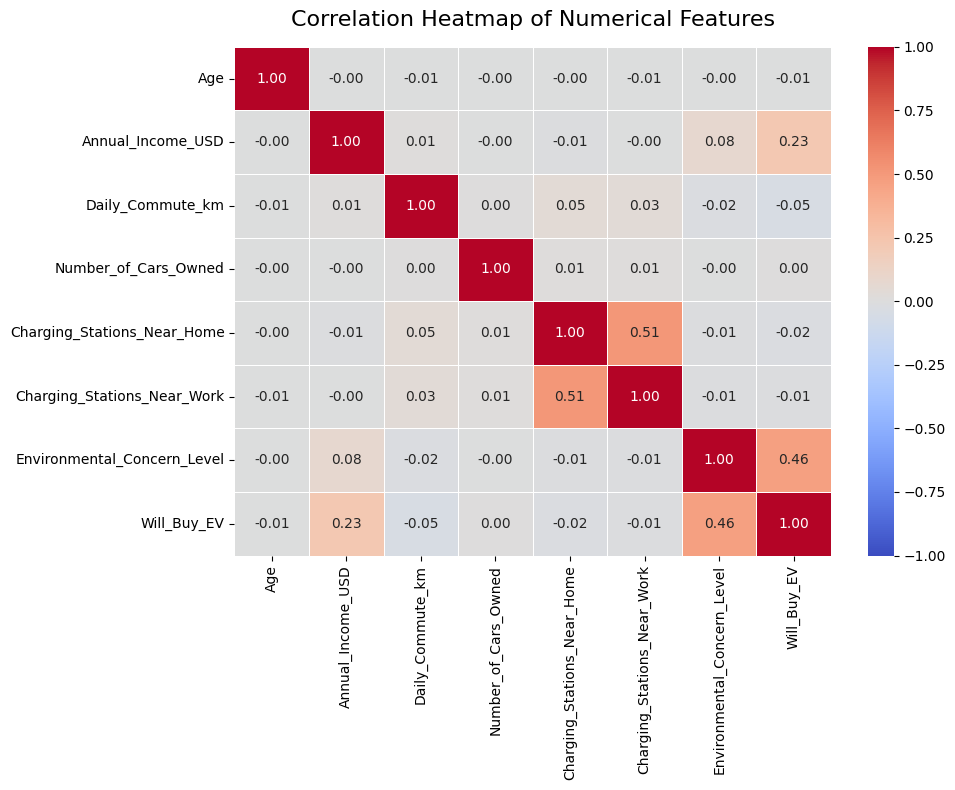

In [ ]:
import seaborn as sns

# 1. Select only numerical columns (and exclude ID columns if needed)
numerical_df = df_train.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix (Pearson correlation by default)
corr_matrix = numerical_df.corr()

# 3. Set up the matplotlib figure size
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation numbers inside the squares
    cmap='coolwarm',     # Color palette (Blue = Negative, White = None, Red = Positive)
    fmt=".2f",           # Round the numbers to 2 decimal places
    vmin=-1, vmax=1,     # Set color scale limits between -1 and 1
    linewidths=0.5       # Add small gaps between the squares
)

# 5. Add titles and show plot
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
df_train.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender', 'City_Type',
       'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
       'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [ ]:
# Encode specific columns and drop the first category to avoid multicollinearity
df_encoded = pd.get_dummies(df_train, columns=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'], drop_first=True, dtype=int)


In [ ]:
df_encoded_test = pd.get_dummies(df_test, columns=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'], drop_first=True, dtype=int)


In [ ]:
df_encoded.describe().T[['min', 'max']]

,min,max
Age,25.0,69.0
Annual_Income_USD,30000.0,188549.0
Daily_Commute_km,5.0,98.7
Number_of_Cars_Owned,1.0,4.0
Charging_Stations_Near_Home,0.0,14.0
Charging_Stations_Near_Work,0.0,19.0
Environmental_Concern_Level,1.0,5.0
Will_Buy_EV,0.0,1.0
Gender_Male,0.0,1.0
Gender_Other,0.0,1.0


In [ ]:
# 1. Create Training features and Training target
X = df_encoded.drop(columns=['Will_Buy_EV'])
y = df_encoded['Will_Buy_EV']

In [ ]:
print(X.shape)
print(y.shape)

(668665, 18)
(668665,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (534932, 18)
X_valid: (133733, 18)
y_train: (534932,)
y_valid: (133733,)


In [ ]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_valid.value_counts(normalize=True))

Original:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64

Training:
Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64

Validation:
Will_Buy_EV
0    0.825354
1    0.174646
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("X_train_scaled:", X_train_scaled.shape)
print("X_valid_scaled:", X_valid_scaled.shape)

X_train_scaled: (534932, 18)
X_valid_scaled: (133733, 18)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_valid_proba = model_lr.predict_proba(X_valid_scaled)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_valid, y_valid_proba)

print("Logistic Regression ROC-AUC:", roc_auc)

Logistic Regression ROC-AUC: 0.937968489545312


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_valid_pred = model_lr.predict(X_valid_scaled)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("Precision:", precision_score(y_valid, y_valid_pred))
print("Recall:", recall_score(y_valid, y_valid_pred))
print("F1 Score:", f1_score(y_valid, y_valid_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

Accuracy: 0.8949174848391945
Precision: 0.7166208727238859
Recall: 0.6588456927556089
F1 Score: 0.686519886680497

Confusion Matrix:
[[104292   6085]
 [  7968  15388]]


In [ ]:
print(classification_report(y_valid, y_valid_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94    110377
           1       0.72      0.66      0.69     23356

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733



In [ ]:
y_valid_pred

array([0, 0, 1, ..., 1, 0, 0])

In [ ]:
y_valid_proba

array([0.04497766, 0.04913827, 0.75673402, ..., 0.86059148, 0.05246746,
       0.06313762])

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

model_hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model_hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200,
                               random_state=42)

In [ ]:
y_valid_proba_hgb = model_hgb.predict_proba(X_valid)[:, 1]

roc_auc_hgb = roc_auc_score(
    y_valid,
    y_valid_proba_hgb
)

print("HistGradientBoosting ROC-AUC:", roc_auc_hgb)

HistGradientBoosting ROC-AUC: 0.9411577158629245


In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostClassifier

cat_cols = [
    'Gender',
    'City_Type',
    'Current_Car_Type',
    'Home_Charging_Possible',
    'Subsidy_Available',
    'Range_Anxiety_Level'
]

X_cat = df_train.drop(columns=['Will_Buy_EV'])
y_cat = df_train['Will_Buy_EV']

In [ ]:
print(y_cat.isna().sum())
print(y_cat.value_counts())

0
Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64


In [ ]:
X_cat_train, X_cat_valid, y_cat_train, y_cat_valid = train_test_split(
    X_cat,
    y_cat,
    test_size=0.20,
    random_state=42,
    stratify=y_cat
)

In [ ]:
model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model_cat.fit(
    X_cat_train,
    y_cat_train,
    cat_features=cat_cols,
    eval_set=(X_cat_valid, y_cat_valid),
    early_stopping_rounds=50
)

0:	test: 0.9322243	best: 0.9322243 (0)	total: 3.08s	remaining: 25m 36s
100:	test: 0.9396904	best: 0.9396904 (100)	total: 2m	remaining: 7m 55s
200:	test: 0.9402558	best: 0.9402558 (200)	total: 3m 52s	remaining: 5m 45s
300:	test: 0.9406449	best: 0.9406449 (300)	total: 5m 35s	remaining: 3m 41s
400:	test: 0.9409665	best: 0.9409665 (400)	total: 7m 26s	remaining: 1m 50s
499:	test: 0.9411550	best: 0.9411550 (499)	total: 9m 15s	remaining: 0us

bestTest = 0.9411550075
bestIteration = 499



CatBoostClassifier(depth=7, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
y_valid_proba_cat = model_cat.predict_proba(X_cat_valid)[:, 1]

roc_auc_cat = roc_auc_score(
    y_cat_valid,
    y_valid_proba_cat
)

print("CatBoost ROC-AUC:", roc_auc_cat)

CatBoost ROC-AUC: 0.9411550075253693


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model_hgb,
    X_valid,
    y_valid,
    scoring='roc_auc',
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

print(importance)

                        Feature    Importance
6   Environmental_Concern_Level  1.917540e-01
15        Subsidy_Available_Yes  1.647582e-01
1             Annual_Income_USD  2.883946e-02
16      Range_Anxiety_Level_Low  1.427371e-02
2              Daily_Commute_km  1.415729e-03
0                           Age  6.824402e-04
17   Range_Anxiety_Level_Medium  5.976120e-04
14   Home_Charging_Possible_Yes  3.704924e-04
4   Charging_Stations_Near_Home  1.882917e-04
5   Charging_Stations_Near_Work  3.612274e-05
3          Number_of_Cars_Owned  1.835854e-05
13       Current_Car_Type_Truck  1.123354e-05
12       Current_Car_Type_Sedan  7.027312e-06
7                   Gender_Male  4.986168e-06
9            City_Type_Suburban -4.506138e-07
8                  Gender_Other -1.122461e-06
10              City_Type_Urban -3.320642e-06
11         Current_Car_Type_SUV -1.179270e-05


In [ ]:
print(df_test.shape)
print(df_test.columns)

(286571, 13)
Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender', 'City_Type',
       'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
       'Range_Anxiety_Level'],
      dtype='object')


In [ ]:
print(X.columns.tolist())

['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other', 'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV', 'Current_Car_Type_Sedan', 'Current_Car_Type_Truck', 'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes', 'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium']


In [105]:
print(df_encoded_test.shape)
print(df_encoded_test.columns.tolist())

(286571, 18)
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other', 'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV', 'Current_Car_Type_Sedan', 'Current_Car_Type_Truck', 'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes', 'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium']


In [106]:
print("Columns match:", list(X.columns) == list(df_encoded_test.columns))

Columns match: True


In [107]:
from sklearn.ensemble import HistGradientBoostingClassifier

final_hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

final_hgb.fit(X, y)

print("Final HGB model trained successfully!")

Final HGB model trained successfully!


In [108]:
test_predictions = final_hgb.predict_proba(df_encoded_test)[:, 1]

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 286571
First 10 predictions:
[8.73923381e-03 2.04143957e-02 6.46982582e-03 3.68660948e-03
 1.68748890e-02 4.88759841e-03 3.73097524e-01 4.78352880e-04
 6.61088800e-01 4.11979246e-03]


In [110]:
sample_submission = pd.read_csv('/content/sample_submission.csv')

print(sample_submission.shape)
print(sample_submission.head())

(286571, 2)
       id  Will_Buy_EV
0  668665     0.174645
1  668666     0.174645
2  668667     0.174645
3  668668     0.174645
4  668669     0.174645


In [111]:
submission = sample_submission.copy()

submission['Will_Buy_EV'] = test_predictions

print(submission.head(10))

       id  Will_Buy_EV
0  668665     0.008739
1  668666     0.020414
2  668667     0.006470
3  668668     0.003687
4  668669     0.016875
5  668670     0.004888
6  668671     0.373098
7  668672     0.000478
8  668673     0.661089
9  668674     0.004120


In [112]:
print("Shape:", submission.shape)

print("\nMissing values:")
print(submission.isnull().sum())

print("\nPrediction minimum:", submission['Will_Buy_EV'].min())
print("Prediction maximum:", submission['Will_Buy_EV'].max())

print("\nNumber of unique predictions:",
      submission['Will_Buy_EV'].nunique())

Shape: (286571, 2)

Missing values:
id             0
Will_Buy_EV    0
dtype: int64

Prediction minimum: 0.00012597692685915415
Prediction maximum: 0.983175194115545

Number of unique predictions: 285205


In [113]:
submission.to_csv('/content/submission.csv', index=False)

print("submission.csv created successfully!")

submission.csv created successfully!
